In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['kennedybruecke'].sum())
header = 'kennedybruecke'

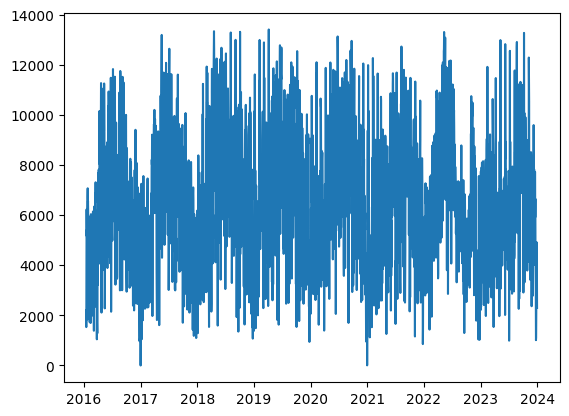

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [4]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

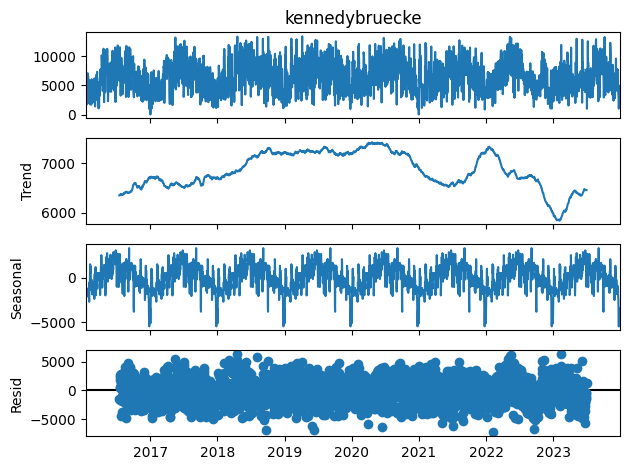

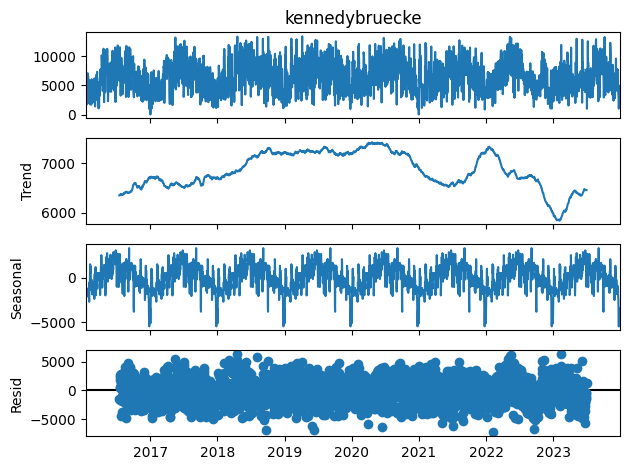

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -4.8869
p-value = 0.0000


In [7]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [8]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [9]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_13180\3224188387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)


Test statistic = -6.4785
P-value = 0.0000


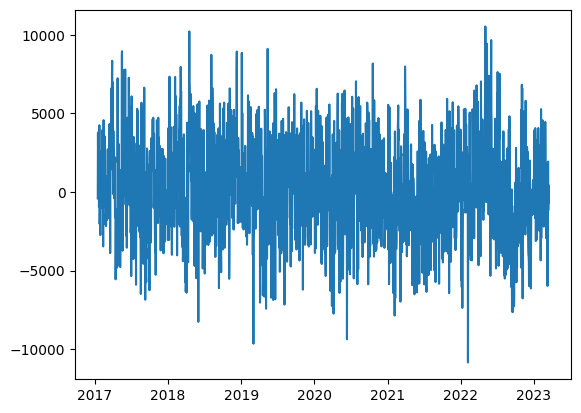

In [10]:
plt.plot(df_train.loc[:,'differences'] )

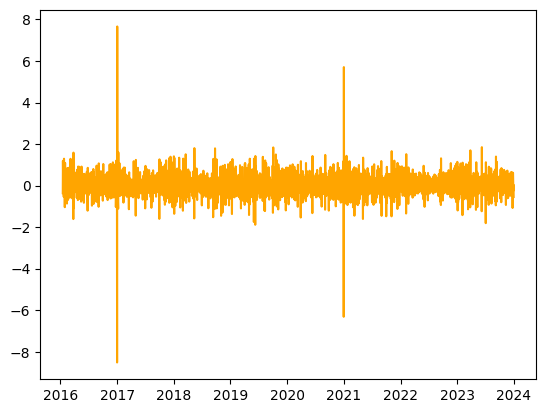

In [11]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [12]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -19.4438
P-value = 0.0000


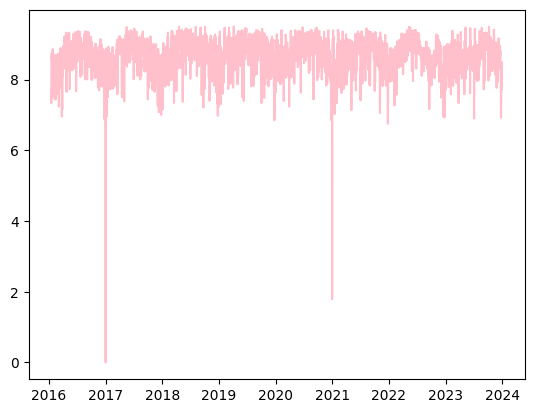

In [13]:
plt.plot(df['log'], color='pink')

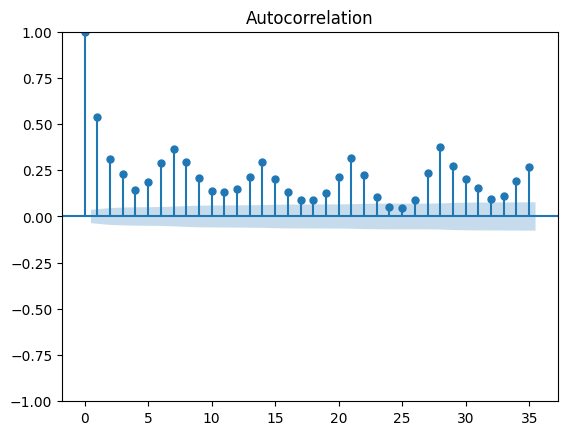

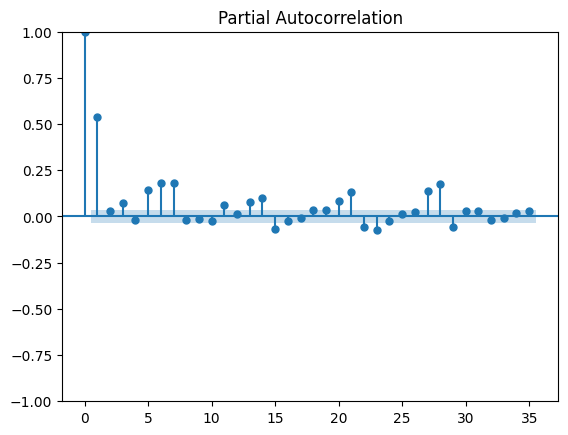

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [15]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



In [16]:
def ma_arima():
    for i in range(1, 3):
        p, d, q = i, 1, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q))
        result = arima.fit()
        #print(result.summary())
        print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q))
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date, end=future_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:future_date, header],
             color='orange', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 50 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -1942.2390, AIC: 3888.4779


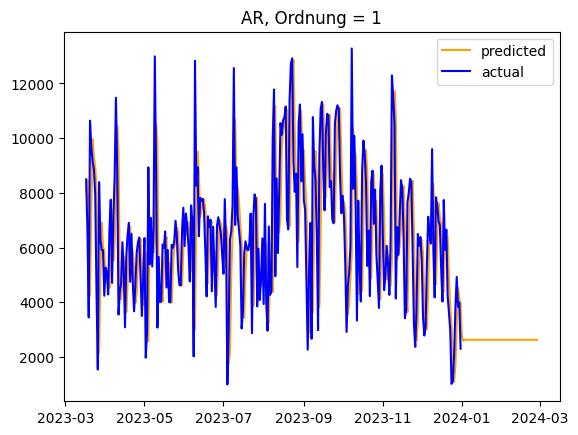

mean absolute error (mae): ARIMA: 6546.4162, simple: 1900.1207
mean squared error (mse): ARIMA: 48954186.4710, simple: 6456589.1966
mean absolute percentage error (mape): ARIMA: 0.3593, simple: 0.3571
Log Likelihood: -1854.5063, AIC: 3715.0126


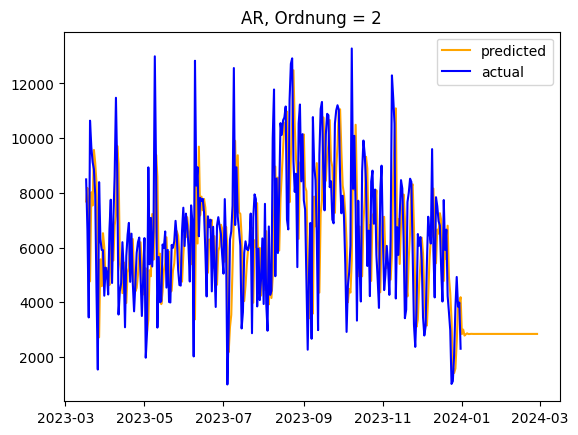

mean absolute error (mae): ARIMA: 6546.4156, simple: 1900.1207
mean squared error (mse): ARIMA: 48954241.4474, simple: 6456589.1966
mean absolute percentage error (mape): ARIMA: 0.3595, simple: 0.3571
Log Likelihood: -1823.6520, AIC: 3655.3039


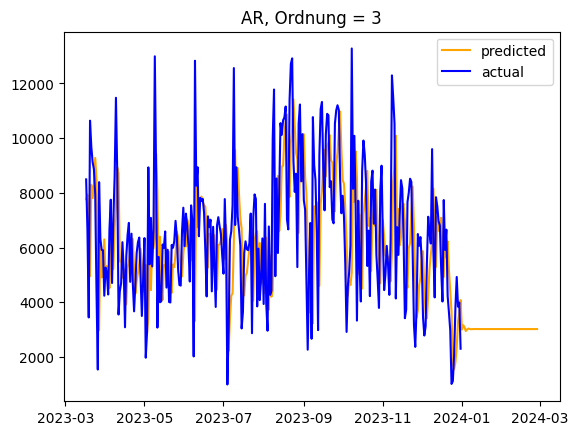

mean absolute error (mae): ARIMA: 6546.4152, simple: 1900.1207
mean squared error (mse): ARIMA: 48954290.8487, simple: 6456589.1966
mean absolute percentage error (mape): ARIMA: 0.3576, simple: 0.3571
Log Likelihood: -1775.8441, AIC: 3561.6882


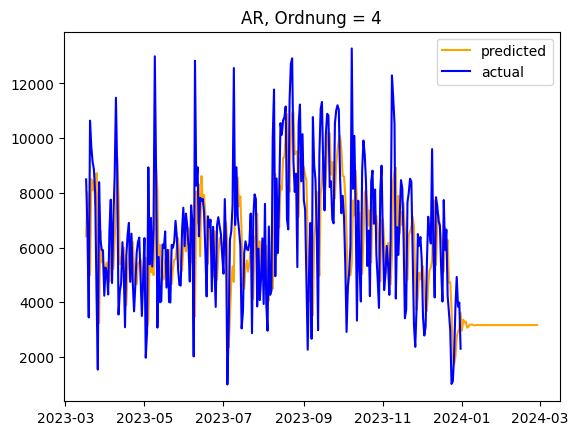

mean absolute error (mae): ARIMA: 6546.4151, simple: 1900.1207
mean squared error (mse): ARIMA: 48954302.1692, simple: 6456589.1966
mean absolute percentage error (mape): ARIMA: 0.3466, simple: 0.3571


In [17]:
for i in range(1, 5):
    p, d, q = i, 1, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='orange', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 50 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [18]:
df_r

,kennedybruecke,scaled,log,differences,predicted_mean,crossings
2016-01-16,2212.000000,2212.835135,7.702030,NaN,NaN,NaN
2016-01-17,1533.000000,1533.885742,7.335559,NaN,NaN,NaN
2016-01-18,5055.000000,5055.623239,8.528256,NaN,NaN,NaN
2016-01-19,6233.000000,6233.535440,8.737699,NaN,NaN,NaN
2016-01-20,5167.000000,5167.614892,8.550167,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-02-24,3163.702683,NaN,NaN,NaN,8.05974,3163.702683
2024-02-25,3163.702683,NaN,NaN,NaN,8.05974,3163.702683
2024-02-26,3163.702683,NaN,NaN,NaN,8.05974,3163.702683
2024-02-27,3163.702683,NaN,NaN,NaN,8.05974,3163.702683


Log Likelihood: -1942.2390, AIC: 3888.4779


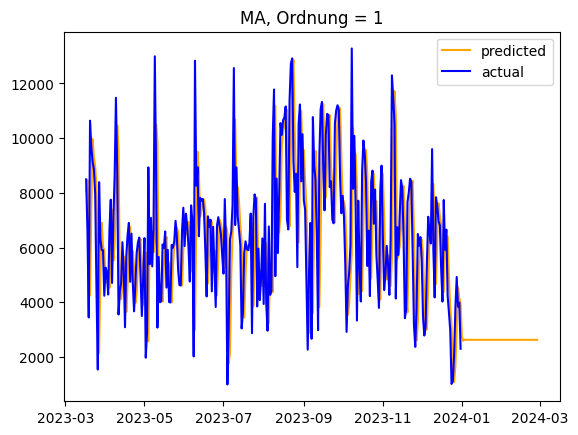

mean absolute error (mae): ARIMA: 6546.4162, simple: 1900.1207
mean squared error (mse): ARIMA: 48954186.4710, simple: 6456589.1966
mean absolute percentage error (mape): ARIMA: 0.3593, simple: 0.3571
Log Likelihood: -1854.5063, AIC: 3715.0126


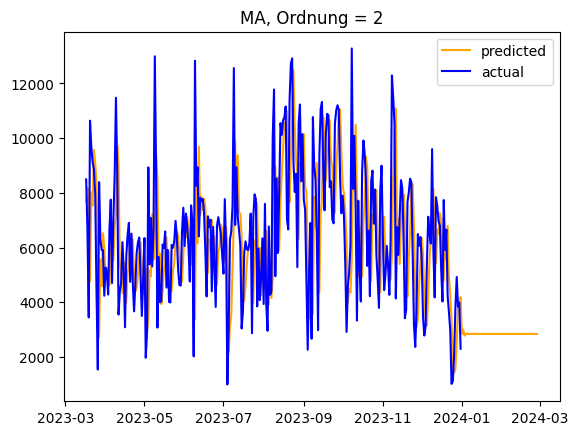

mean absolute error (mae): ARIMA: 6546.4156, simple: 1900.1207
mean squared error (mse): ARIMA: 48954241.4474, simple: 6456589.1966
mean absolute percentage error (mape): ARIMA: 0.3595, simple: 0.3571


In [19]:
ma_arima()

Seasonal ARIMA

In [20]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,72192,123487,141401,211634,232711,223142,247797,243278,269091,180288,165473,154398
2017,134774,130781,202978,201958,258693,259029,246584,223262,212776,201019,175723,124805
2018,154831,164067,183071,249200,251517,263973,250629,238372,227598,222998,210519,173180
2019,164508,205825,203343,218147,254748,261274,245107,252735,233356,227536,201898,173183
2020,196682,172305,192434,218057,259887,260501,275996,262594,266179,227221,199606,155742
2021,152323,174454,189411,199321,190138,232026,216494,236892,252307,206681,187332,174689
2022,163386,156977,253585,222104,297967,263419,237817,191570,154743,157666,227418,112062
2023,173889,175447,207031,171770,180301,198583,186218,258426,244494,214720,192657,152345


In [21]:
#Mittelwertbereinigung
df['days_noyear'] = pd.to_datetime(df.index).strftime('%m-%d')
df['day_mean'] = df.groupby('days_noyear')['log'].transform('mean')
df['cleaned_by_mean'] = df['log'] - df['day_mean']
display(df)

,kennedybruecke,scaled,log,first_logged_diff,differences,days_noyear,day_mean,cleaned_by_mean
2016-01-16,2212,2212.835135,7.702030,NaN,NaN,01-16,8.435923,-0.733893
2016-01-17,1533,1533.885742,7.335559,-0.366470,NaN,01-17,8.340568,-1.005009
2016-01-18,5055,5055.623239,8.528256,1.192697,NaN,01-18,8.624710,-0.096453
2016-01-19,6233,6233.535440,8.737699,0.209443,NaN,01-19,8.536420,0.201279
2016-01-20,5167,5167.614892,8.550167,-0.187532,NaN,01-20,8.469331,0.080836
...,...,...,...,...,...,...,...,...
2023-12-27,3808,3808.716181,8.245047,0.610785,NaN,12-27,8.072798,0.172250
2023-12-28,4923,4923.633077,8.501802,0.256755,NaN,12-28,8.196939,0.304863
2023-12-29,3836,3836.714094,8.252372,-0.249430,NaN,12-29,8.104523,0.147849
2023-12-30,3985,3985.702989,8.290469,0.038097,NaN,12-30,8.104676,0.185793


In [22]:
df['weekday'] = df.index.dayofweek  # 0 = Montag, 6 = Sonntag
weekly_pattern = df.groupby('weekday')[header].mean()
print(weekly_pattern)

weekday
0    7210.554217
1    7588.163855
2    7709.824096
3    7362.626506
4    7103.154217
5    5764.293269
6    4856.889423
Name: kennedybruecke, dtype: float64


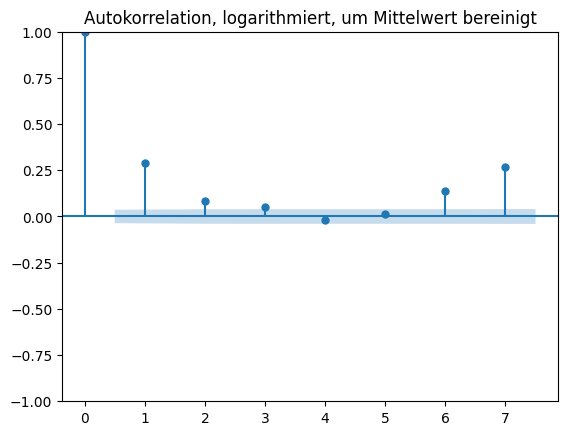

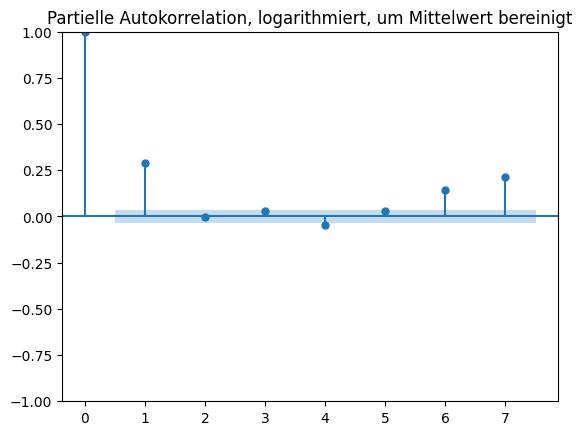

In [23]:
lags  = 7
plot_acf(df['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()
#für Order-Ebene, Lag 1 signifikant

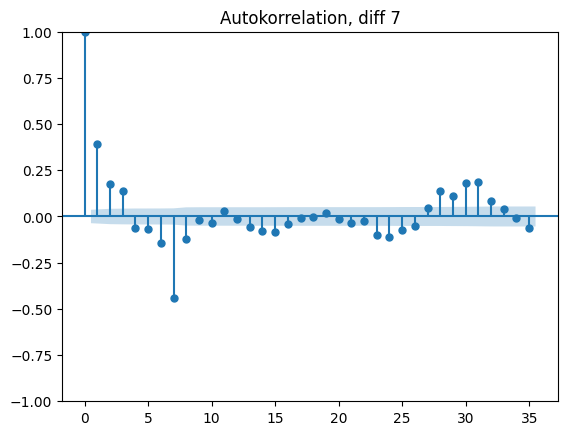

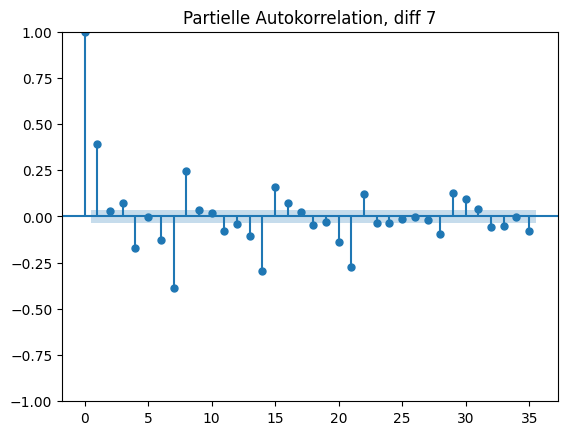

In [24]:
diffs = df[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [25]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df) * 0.8)
df_train_seas = df.iloc[:end_train]
df_test_seas = df.iloc[end_train:]

seasonal = 7
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,7) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,7) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,7) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

ARIMA (0,0,0)x(0,1,0,7) LL -2101.7866, AIC: 4205.5731
ARIMA (0,1,0)x(0,1,0,7) LL -2473.4922, AIC: 4948.9845
ARIMA (1,0,0)x(0,1,1,7) LL -1347.9307, AIC: 2701.8614
ARIMA (1,0,0)x(0,1,2,7) LL -1338.9881, AIC: 2685.9761
ARIMA (1,1,0)x(0,1,2,7) LL -1529.4537, AIC: 3066.9074
ARIMA (0,0,1)x(0,1,2,7) LL -1398.5331, AIC: 2805.0661
ARIMA (0,1,1)x(0,1,2,7) LL -1356.6095, AIC: 2721.2191
ARIMA (0,1,1)x(2,1,0,7) LL -1672.1368, AIC: 3352.2735


In [26]:
print(result4.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                    log   No. Observations:                 2326
Model:             SARIMAX(1, 0, 0)x(0, 1, [1, 2], 7)   Log Likelihood               -1338.988
Date:                                Tue, 11 Feb 2025   AIC                           2685.976
Time:                                        18:14:22   BIC                           2708.972
Sample:                                    01-16-2016   HQIC                          2694.357
                                         - 05-29-2022                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4422      0.008     55.508      0.000       0.427       0.458
ma.

In [27]:
results_final = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start='2022-05-30', end='2024-12-31')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)


            predicted_mean     unlogged  new_predict
2022-05-30        8.763836  6398.609348  6398.086212
2022-05-31        8.852545  6992.164006  6991.685112
2022-06-01        8.935674  7598.259058  7597.825342
2022-06-02        8.814800  6733.161602  6732.663402
2022-06-03        8.824726  6800.323757  6799.830564
...                    ...          ...          ...
2024-12-27        8.818364  6757.203921  6756.707514
2024-12-28        8.657676  5754.148217  5753.577045
2024-12-29        8.420082  4537.275418  4536.613542
2024-12-30        8.855477  7012.690718  7012.213355
2024-12-31        8.898375  7320.065772  7319.611319

[947 rows x 3 columns]


Text(0.5, 1.0, 'Prognose')

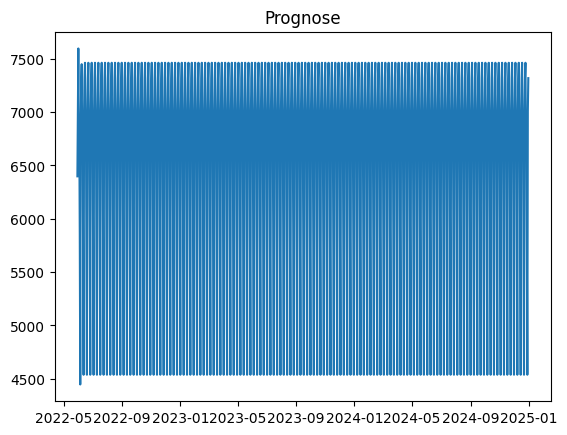

In [28]:
plt.plot(y_pred_no_update['new_predict'])
plt.title('Prognose')

Text(0.5, 1.0, 'tatsächliche Daten')

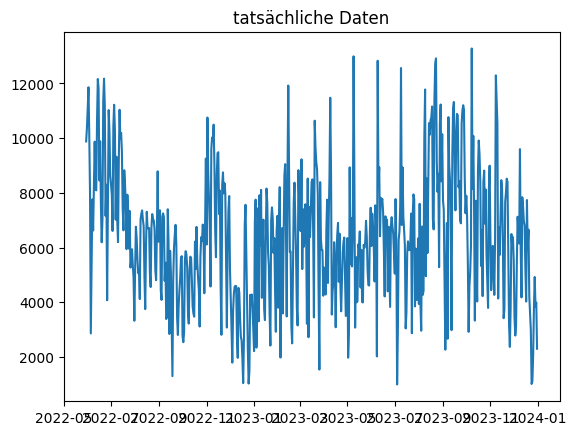

In [29]:
plt.plot(df_test_seas[header])
plt.title('tatsächliche Daten')

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal), freq='D')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2022-05-30', end='2024-12-31')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

,predicted_mean,unlogged,final_data
2022-05-30,8.763836,6398.609348,6398.086212
2022-05-31,8.852545,6992.164006,6991.685112
2022-06-01,8.935674,7598.259058,7597.825342
2022-06-02,8.814800,6733.161602,6732.663402
2022-06-03,8.824726,6800.323757,6799.830564
...,...,...,...
2024-12-27,8.818364,6757.203921,6756.707514
2024-12-28,8.657676,5754.148217,5753.577045
2024-12-29,8.420082,4537.275418,4536.613542
2024-12-30,8.855477,7012.690718,7012.213355


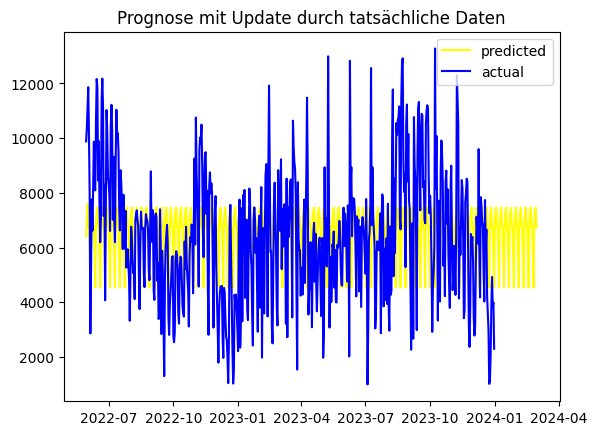

In [31]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2022-05-30'
end_date = '2024-03-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [32]:
mape_bound = 100

df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-31', header]))
mape_arima = sum(mape_arima)/len(mape_arima)


print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_13180\1728239483.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_13180\1728239483.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:,'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_1

mean absolute error (mae): ARIMA: 1768.1995
mean squared error (mse): ARIMA: 5057731.9284
mean absolute percentage error (mape): ARIMA: 0.3779


Monatlich


In [33]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     151573.125
2     162917.875
3     196656.750
4     211523.875
5     240745.250
6     245243.375
7     238330.250
8     238391.125
9     232568.000
10    204766.125
11    195078.250
12    152550.500
Name: kennedybruecke, dtype: float64


In [34]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [35]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [36]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,kennedybruecke
year-month,,
2016-01-01,2016-01-01,72192
2016-02-01,2016-02-01,123487
2016-03-01,2016-03-01,141401
2016-04-01,2016-04-01,211634
2016-05-01,2016-05-01,232711
...,...,...
2023-08-01,2023-08-01,258426
2023-09-01,2023-09-01,244494
2023-10-01,2023-10-01,214720


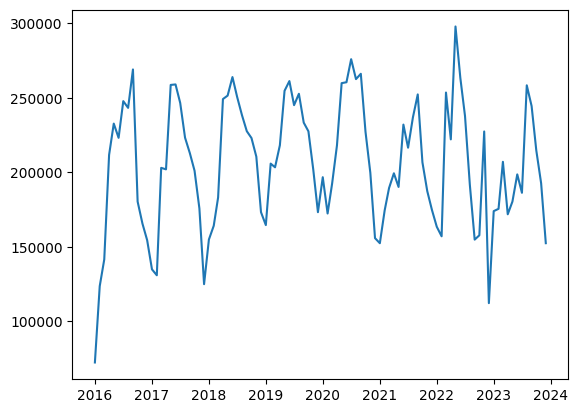

In [37]:
plt.plot(df_month[header])

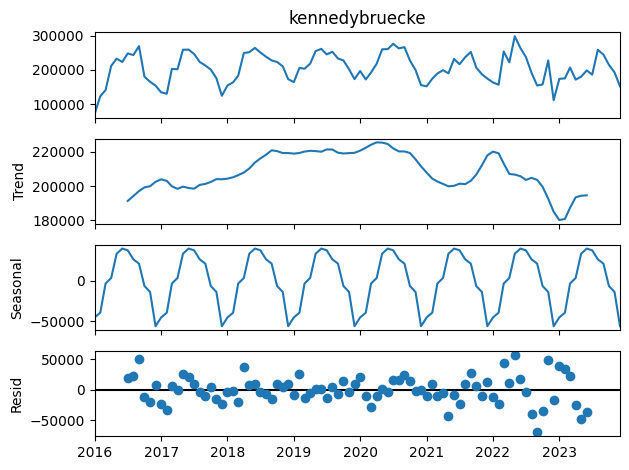

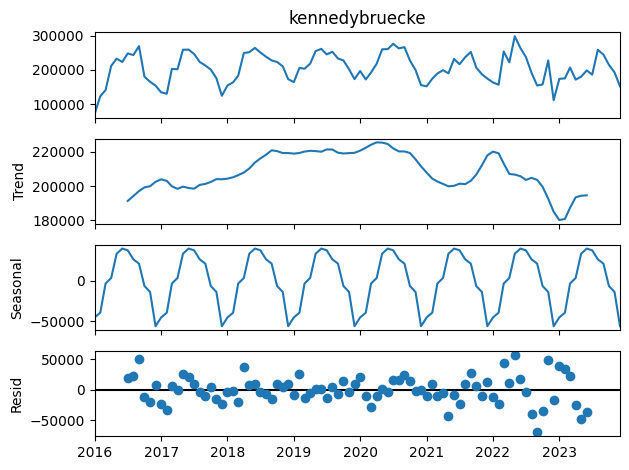

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [39]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -6.3630
p-value = 0.0000


In [40]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,kennedybruecke,scaled,log
year-month,,,,
2016-01-01,2016-01-01,72192,1.000000,0.000000
2016-02-01,2016-02-01,123487,67697.449873,11.122804
2016-03-01,2016-03-01,141401,91339.407237,11.422338
2016-04-01,2016-04-01,211634,184029.235952,12.122850
2016-05-01,2016-05-01,232711,211845.554774,12.263613
...,...,...,...,...
2023-08-01,2023-08-01,258426,245782.862669,12.412204
2023-09-01,2023-09-01,244494,227396.139993,12.334449
2023-10-01,2023-10-01,214720,188101.976849,12.144740


In [41]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [42]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -2.0818
P-value = 0.2519


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_13180\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


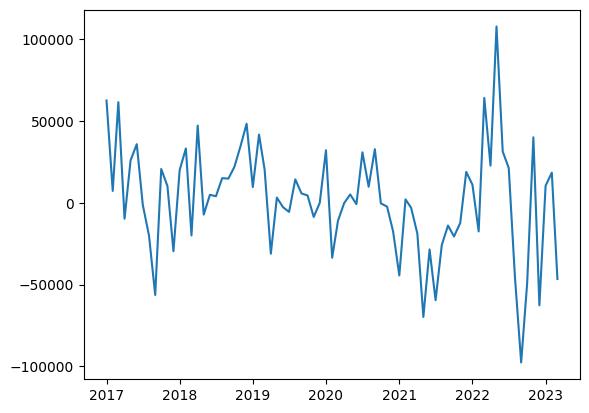

In [43]:
plt.plot(df_train['differences'])

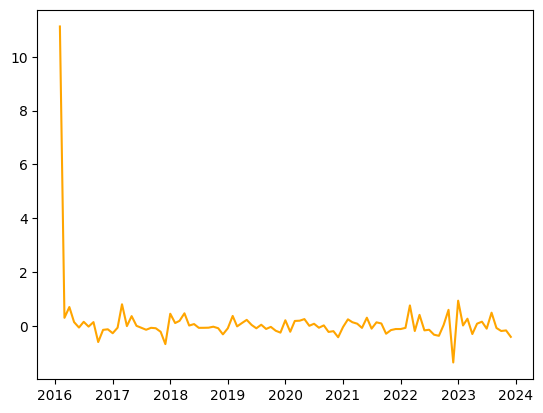

In [44]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [45]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -7.7024
P-value = 0.0000


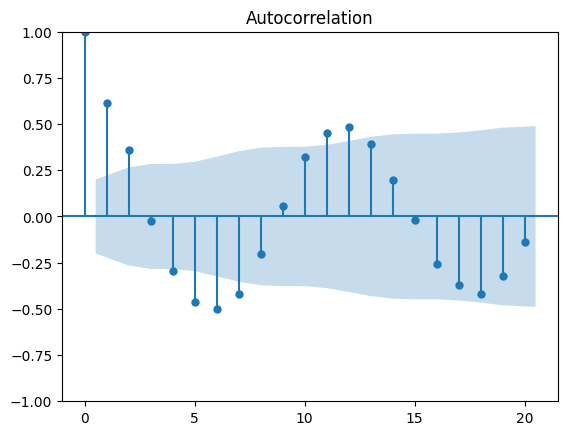

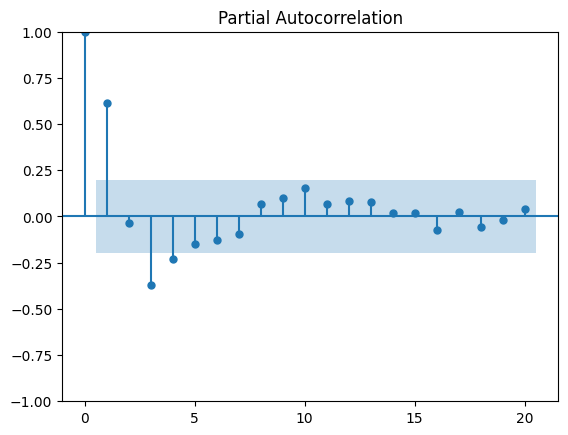

In [46]:
plot_acf(df_month[header])
plot_pacf(df_month[header])
plt.show()

In [47]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,kennedybruecke,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,72192,1.000000,0.000000,NaN,1,10.214435,-10.214435
2016-02-01,2016-02-01,123487,67697.449873,11.122804,11.122804,2,11.652058,-0.529254
2016-03-01,2016-03-01,141401,91339.407237,11.422338,0.299534,3,11.979425,-0.557087
2016-04-01,2016-04-01,211634,184029.235952,12.122850,0.700512,4,12.110420,0.012430
2016-05-01,2016-05-01,232711,211845.554774,12.263613,0.140763,5,12.286554,-0.022941
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,258426,245782.862669,12.412204,0.490575,8,12.289139,0.123064
2023-09-01,2023-09-01,244494,227396.139993,12.334449,-0.077755,9,12.232827,0.101622
2023-10-01,2023-10-01,214720,188101.976849,12.144740,-0.189709,10,12.054698,0.090041


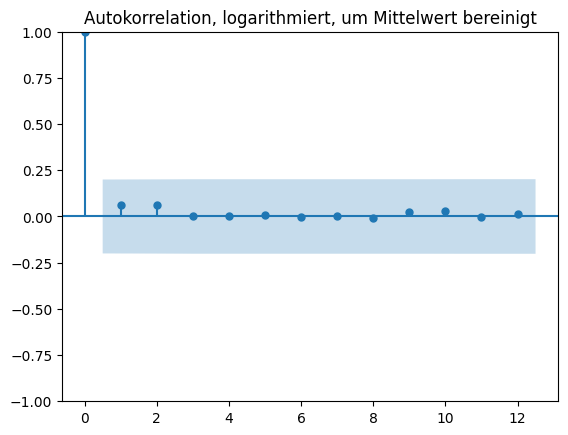

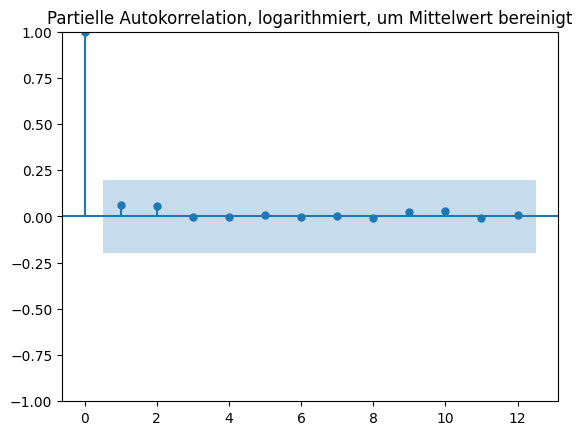

In [48]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

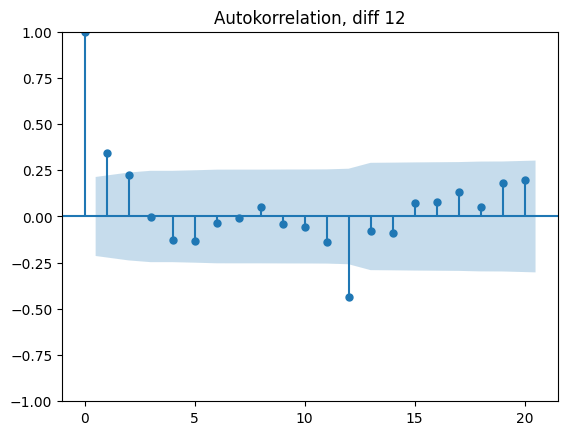

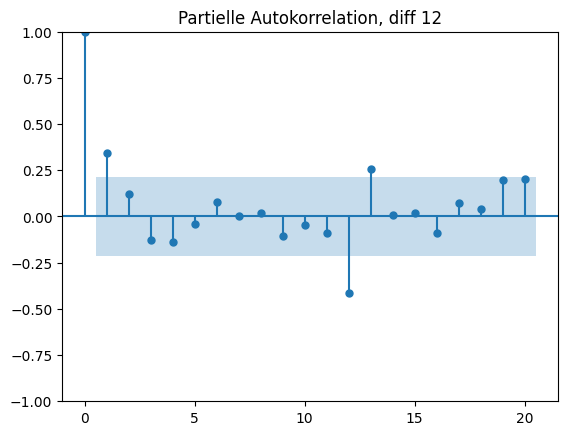

In [49]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [50]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -128.1763, AIC: 258.3526
ARIMA (0,1,0)x(0,1,0,12) LL -127.2534, AIC: 256.5068
ARIMA (1,0,0)x(0,1,1,12) LL -127.9753, AIC: 261.9507
ARIMA (1,0,0)x(0,1,2,12) LL -127.9749, AIC: 263.9498
ARIMA (1,1,0)x(0,1,2,12) LL -124.6737, AIC: 257.3474
ARIMA (0,0,1)x(0,1,2,12) LL -128.0888, AIC: 264.1776
ARIMA (0,1,1)x(0,1,2,12) LL -125.8718, AIC: 257.7436
ARIMA (0,1,1)x(2,1,0,12) LL -125.8359, AIC: 259.6718


In [51]:
print(result7.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                  log   No. Observations:                   87
Model:             SARIMAX(0, 1, 1)x(0, 1, [2], 12)   Log Likelihood                -125.872
Date:                              Tue, 11 Feb 2025   AIC                            257.744
Time:                                      18:15:08   BIC                            264.656
Sample:                                  01-01-2016   HQIC                           260.501
                                       - 03-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4761      0.060     -7.940      0.000      -0.594      -0.359
ma.S.L24      -0.02

In [52]:
start_date = '2023-04-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal)).fit()
y_pred_no_update = results_final.predict(start='2023-04-01', end='2024-12-01')
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean       unlogged    new_predict
2023-04-01       12.048140  170781.457007  201595.883935
2023-05-01       12.467153  259666.273909  268945.747799
2023-06-01       12.292173  217983.071044  237361.522999
2023-07-01       12.153844  189822.383677  216023.587831
2023-08-01       11.820370  135994.480042  175237.072110
2023-09-01       11.449437   93848.499698  143302.191244
2023-10-01       11.486243   97367.028545  145968.253313
2023-11-01       12.081781  176624.397352  206023.200665
2023-12-01       10.713416   44954.922788  106254.516923
2024-01-01       11.651724  114889.299890  159245.240664
2024-02-01       11.676850  117812.500713  161460.210378
2024-03-01       11.925031  150999.411289  186606.618812
2024-04-01       11.891872  146074.466209  182874.886079
2024-05-01       12.296479  218923.898057  238074.407083
2024-06-01       12.135485  186369.206840  213407.044331
2024-07-01       11.998241  162468.703483  195297.138686
2024-08-01       11.678514  118

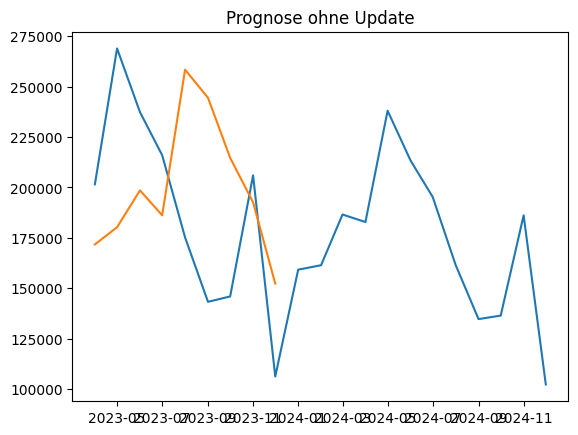

mean absolute error (mae): ARIMA: 55515.9900
mean squared error (mse): ARIMA: 3925510231.3827
mean absolute percentage error (mape): ARIMA: 0.2721


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_13180\1074150843.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_13180\1074150843.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykern

In [53]:
plt.plot(y_pred_no_update['new_predict'])
plt.plot(df_test_seas[header])

plt.title('Prognose ohne Update')
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [54]:
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2023-04-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])
tmp

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,predicted_mean,unlogged,final_data
2023-04-01,12.048140,170781.457007,201595.883935
2023-05-01,12.329894,226362.760335,243710.986863
2023-06-01,11.913109,149209.888304,185250.660239
2023-07-01,11.833181,137747.945563,176565.709196
2023-08-01,11.546044,103367.295988,150514.780038
2023-09-01,11.628889,112295.522983,157279.882263
2023-10-01,12.035335,168608.571561,199949.443699
2023-11-01,12.688189,323899.800257,317616.819033
2023-12-01,10.947005,56783.722524,115217.443097
2024-01-01,12.211249,201038.010208,224521.899987


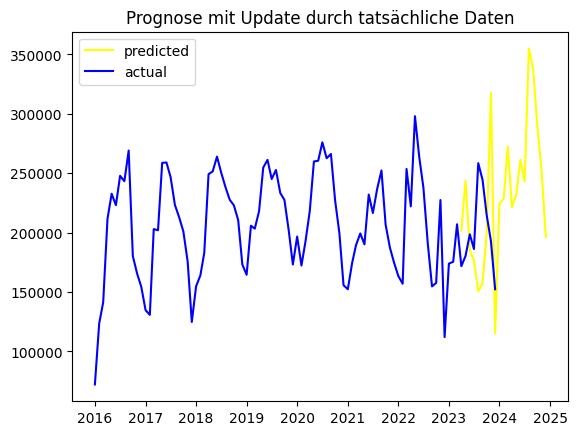

In [55]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2016-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
            color='yellow', label='predicted')
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [56]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 54244.8635
mean squared error (mse): ARIMA: 4627115855.7717
mean absolute percentage error (mape): ARIMA: 0.2644
